# 3×2 FaIR concentration and radiative efficiency panels

This notebook plots a 3×2 panel for CO$_2$, CH$_4$, and N$_2$O:

- **Left column:** concentration
- **Right column:** radiative efficiency (RE)

Each panel shows the FaIR ensemble median with a 5–95% uncertainty band for the selected SSPs.

In [1]:
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["mathtext.rm"] = "Times New Roman"
mpl.rcParams["axes.unicode_minus"] = False
plt.style.use("tableau-colorblind10")


In [5]:

PKL_PATH  = "parameters_C_ERF_lifetime/ERF_C_lifetime_CO2CH4N2O_1001ensemble_dicts_run2026-02-23.pkl"
XLSX_PATH = "parameters_C_ERF_lifetime/ERF_C_lifetime_CO2CH4N2O_2000_2500_run2026-02-23.xlsx"

SSPS = ["ssp119", "ssp126", "ssp245", "ssp585"]

SSP_LABELS = {
    "ssp119": "SSP1-1.9",
    "ssp126": "SSP1-2.6",
    "ssp245": "SSP2-4.5",
    "ssp585": "SSP5-8.5",
}

TABLEAU_COLORS = mpl.rcParams["axes.prop_cycle"].by_key()["color"]
SSP_COLORS = {
    "ssp119": "#3A923A",
    "ssp126": TABLEAU_COLORS[0],
    "ssp245": TABLEAU_COLORS[1],
    "ssp585": TABLEAU_COLORS[3] if len(TABLEAU_COLORS) > 3 else "#595959",
}

GAS_TITLES = {
    "CO2": r"CO$_2$",
    "CH4": r"CH$_4$",
    "N2O": r"N$_2$O",
}

YLABEL_CONC = {
    "CO2": r"CO$_2$ concentration (ppm)",
    "CH4": r"CH$_4$ concentration (ppb)",
    "N2O": r"N$_2$O concentration (ppb)",
}

YLABEL_RE = {
    "CO2": r"CO$_2$ RE (W m$^{-2}$ ppm$^{-1}$)",
    "CH4": r"CH$_4$ RE (W m$^{-2}$ ppb$^{-1}$)",
    "N2O": r"N$_2$O RE (W m$^{-2}$ ppb$^{-1}$)",
}


In [9]:
from matplotlib.ticker import ScalarFormatter

class ScalarFormatterForceFormat(ScalarFormatter):
    def __init__(self, fmt="%1.1f", useMathText=False):
        super().__init__(useMathText=useMathText)
        self.fmt = fmt

    def _set_format(self):
        self.format = self.fmt   # ← NO mathtext wrapping

        
def _safe_get_years_from_sheet(xlsx_path: str, sheet_name: str, fallback_length: int, y_start: int = 2000):
    """
    Prefer explicit Year values from the workbook; otherwise fall back to a simple range.
    """
    try:
        df = pd.read_excel(xlsx_path, sheet_name=sheet_name)
        df.columns = [str(c).strip() for c in df.columns]
        if "Year" in df.columns:
            years = df["Year"].to_numpy(dtype=int)
            if len(years) == fallback_length:
                return years
    except Exception:
        pass

    return np.arange(y_start, y_start + fallback_length)


def _plot_metric_panel(
    ax,
    years,
    ens_dict,
    ssps,
    ssp_colors,
    ssp_labels,
    year_min,
    year_max,
    ylabel,
    band_q=(5, 95),
    band_alpha=0.20,
    legend=False,
):
    qlo, qhi = band_q
    mask = (years >= year_min) & (years <= year_max)

    for ssp in ssps:
        if ssp not in ens_dict:
            continue

        ens = np.asarray(ens_dict[ssp], dtype=float)
        med = np.median(ens, axis=1)
        low = np.percentile(ens, qlo, axis=1)
        high = np.percentile(ens, qhi, axis=1)

        color = ssp_colors[ssp]

        ax.fill_between(
            years[mask], low[mask], high[mask],
            color=color, alpha=band_alpha, linewidth=0
        )
        ax.plot(
            years[mask], med[mask],
            color=color, linewidth=2.4, label=ssp_labels[ssp]
        )

    ax.set_ylabel(ylabel, fontsize=13)
    ax.grid(True, alpha=0.63)
    ax.tick_params(axis="both", labelsize=12)
    #ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))
    sf = ScalarFormatterForceFormat(fmt="%1.1f", useMathText=False)
    sf.set_powerlimits((0, 0))
    ax.yaxis.set_major_formatter(sf)
    

    if legend:
        band_patch = Patch(
            facecolor="lightgray",
            edgecolor="none",
            alpha=band_alpha,
            label="FaIR 5–95%"
        )
        line_handles = [
            Line2D([0], [0], color=ssp_colors[s], lw=2.4, label=ssp_labels[s])
            for s in ssps if s in ens_dict
        ]
        ax.legend(
            handles=[band_patch] + line_handles,
            fontsize=12,
            frameon=True,
            loc="best"
        )


def plot_fair_concentration_re_3x2(
    pkl_path: str,
    xlsx_path: str,
    ssps=SSPS,
    year_min: int = 2000,
    year_max: int = 2300,
    band_q=(5, 95),
    band_alpha: float = 0.20,
    figsize=(17, 13),
    save_path: str | None = None,
    dpi: int = 600,
    save_format: str = "tiff",
):
    with open(pkl_path, "rb") as f:
        payload = pickle.load(f)

    gas_key_map = {
        "CO2": "co2_all_ensemble_dict",
        "CH4": "ch4_all_ensemble_dict",
        "N2O": "n2o_all_ensemble_dict",
    }
    sheet_map_conc = {"CO2": "CO2_C", "CH4": "CH4_C", "N2O": "N2O_C"}
    sheet_map_re   = {"CO2": "CO2_RE", "CH4": "CH4_RE", "N2O": "N2O_RE"}

    fig, axes = plt.subplots(
        nrows=3, ncols=2, figsize=figsize, sharex=True,
        gridspec_kw={"wspace": 0.22, "hspace": 0.28}
    )

    for i, gas in enumerate(["CO2", "CH4", "N2O"]):
        entry = payload[gas_key_map[gas]]

        conc_dict = entry["gas_C"]
        re_dict   = entry["gas_re"]

        sample_len_conc = np.asarray(next(iter(conc_dict.values()))).shape[0]
        sample_len_re   = np.asarray(next(iter(re_dict.values()))).shape[0]

        years_conc = _safe_get_years_from_sheet(
            xlsx_path, sheet_map_conc[gas], fallback_length=sample_len_conc, y_start=2000
        )
        years_re = _safe_get_years_from_sheet(
            xlsx_path, sheet_map_re[gas], fallback_length=sample_len_re, y_start=2000
        )

        ax_left = axes[i, 0]
        ax_right = axes[i, 1]

        _plot_metric_panel(
            ax=ax_left,
            years=years_conc,
            ens_dict=conc_dict,
            ssps=ssps,
            ssp_colors=SSP_COLORS,
            ssp_labels=SSP_LABELS,
            year_min=year_min,
            year_max=year_max,
            ylabel=YLABEL_CONC[gas],
            band_q=band_q,
            band_alpha=band_alpha,
            legend=(i == 0),
        )
        _plot_metric_panel(
            ax=ax_right,
            years=years_re,
            ens_dict=re_dict,
            ssps=ssps,
            ssp_colors=SSP_COLORS,
            ssp_labels=SSP_LABELS,
            year_min=year_min,
            year_max=year_max,
            ylabel=YLABEL_RE[gas],
            band_q=band_q,
            band_alpha=band_alpha,
            legend=False,
        )

        ax_left.set_title(f"{GAS_TITLES[gas]} concentration", fontsize=15)
        ax_right.set_title(f"{GAS_TITLES[gas]} radiative efficiency", fontsize=15)

        ax_left.set_xlim(year_min, year_max)
        ax_right.set_xlim(year_min, year_max)

    axes[-1, 0].set_xlabel("Year", fontsize=13)
    axes[-1, 1].set_xlabel("Year", fontsize=13)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        if save_path.suffix == "":
            save_path = save_path.with_suffix(f".{save_format}")

        save_kwargs = {"dpi": dpi, "bbox_inches": "tight"}
        if save_path.suffix.lower() in [".tif", ".tiff"]:
            save_kwargs["pil_kwargs"] = {"compression": "tiff_lzw"}

        fig.savefig(save_path, **save_kwargs)
        print(f"Saved to: {save_path.resolve()}")

    plt.show()
    return fig, axes


/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_1450/1864075481.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved to: /Users/susierwu/dpLCA_main/dpLCIA/FaIR_dpCFs/output/FaIR_concentration_RE_3x2.png


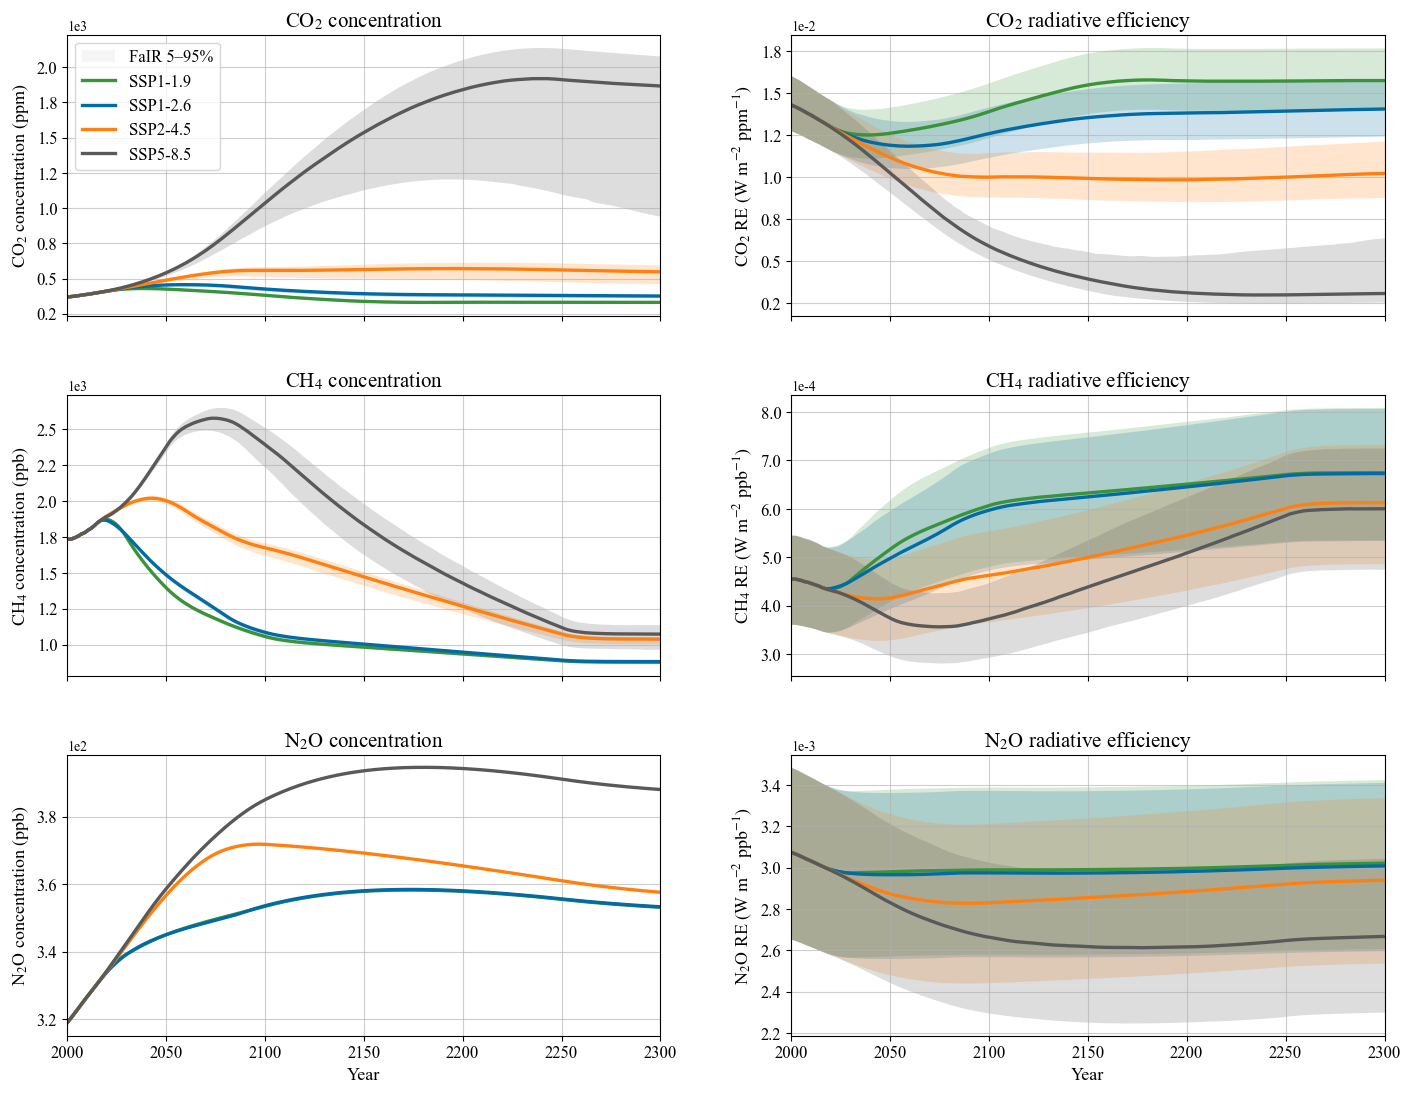

(<Figure size 1700x1300 with 6 Axes>,
 array([[<Axes: title={'center': 'CO$_2$ concentration'}, ylabel='CO$_2$ concentration (ppm)'>,
         <Axes: title={'center': 'CO$_2$ radiative efficiency'}, ylabel='CO$_2$ RE (W m$^{-2}$ ppm$^{-1}$)'>],
        [<Axes: title={'center': 'CH$_4$ concentration'}, ylabel='CH$_4$ concentration (ppb)'>,
         <Axes: title={'center': 'CH$_4$ radiative efficiency'}, ylabel='CH$_4$ RE (W m$^{-2}$ ppb$^{-1}$)'>],
        [<Axes: title={'center': 'N$_2$O concentration'}, xlabel='Year', ylabel='N$_2$O concentration (ppb)'>,
         <Axes: title={'center': 'N$_2$O radiative efficiency'}, xlabel='Year', ylabel='N$_2$O RE (W m$^{-2}$ ppb$^{-1}$)'>]],
       dtype=object))

In [10]:

plot_fair_concentration_re_3x2(
    pkl_path=PKL_PATH,
    xlsx_path=XLSX_PATH,
    year_min=2000,
    year_max=2300,
    save_path="FaIR_concentration_RE_3x2.png",
    dpi=300,
    save_format="png",
)
